In [1]:
import torch
import torch.nn as nn 
import torch.nn.functional as F

In [2]:
vocab = '$abcdefghijklmnopqrstuvwxyz'
vocab_size = len(vocab)
ch_to_i = {char: i for i, char in enumerate(vocab)}
i_to_ch = {i: char for i, char in enumerate(vocab)}

In [3]:
names = []
with open('dlwpt-code-2e/data/p2ch9/names_2022.txt', 'r') as file:
    for line in file:
        name, _, _= line.lower().strip().split(',')
        names.append("$" + name + "$")
        len(names)

In [4]:
equal_probs = F.softmax(torch.ones(vocab_size), dim = 0)
for i in range(5):
    generated = ''
    while True:
        random_int = torch.multinomial(equal_probs, 1).item()
        random_char = i_to_ch[random_int]
        if random_char == '$':
            break
        generated += random_char
    print(f'name {i}: {generated}')

name 0: yusmlxsfvmvfkhzzpumu
name 1: nwardfydatplw
name 2: gyzmiapocftgvxsxopujfcqqtxmdoobtktggam
name 3: lyhfeeco
name 4: gjquamxfjwbasnkdccwojahcztxfogdqffsjyngpynvbmahbhrfbzfxqpzbepvvorzpeiyftynhmfchlnoipqsdxfsxpxkhfakmibejrcuxalqmjgor


Number of names: 31915
Max name length: 17
Min name length: 4
Average name length: 8.052107159642802


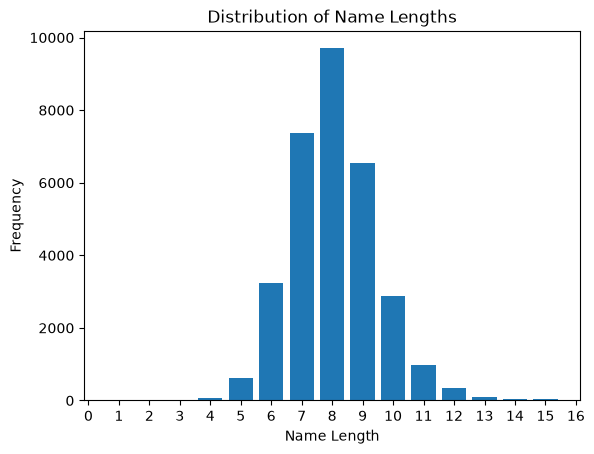

In [5]:
import matplotlib.pyplot as plt


num_names = len(names)
name_lengths = [len(name) for name in names]
max_name_length = max(name_lengths)
min_name_length = min(name_lengths)
print(f"Number of names: {num_names}")
print(f"Max name length: {max_name_length}")
print(f"Min name length: {min_name_length}")
print(f"Average name length: {sum(name_lengths) / num_names}")


plt.hist(name_lengths, bins = range(1, 17), align = 'left', rwidth = 0.8)
plt.xlabel('Name Length')
plt.xticks(range(0, 17))
plt.ylabel('Frequency')
plt.title('Distribution of Name Lengths')
plt.show()

In [6]:
bigram = torch.zeros((vocab_size, vocab_size))
total = 0
for name in names:
    for ch1, ch2 in zip(name, name[1:]):
        ch1_int = ch_to_i[ch1]
        ch2_int = ch_to_i[ch2]
        bigram[ch1_int][ch2_int] += 1
        total += 1
bigram /= total

In [7]:
for i in range(5):
    generated = '$'
    while True:
        bigram_probs = bigram[ch_to_i[generated[-1]]]
        sampled_char = i_to_ch[torch.multinomial(bigram_probs, 1).item()]
        if sampled_char == '$':
            break
        generated += sampled_char
    print(f'name {i}: {generated[1:]}')

name 0: kimamay
name 1: an
name 2: bilysemiemireech
name 3: yn
name 4: aken


In [8]:
example_name = '$ada$'
encode = lambda word: torch.tensor([ch_to_i[c] for c in word])
decode = lambda tensor_i: ''.join(i_to_ch[i.item()] for i in tensor_i)
print(encode(example_name))
print(decode(encode(example_name)))

name_indices = [encode(name) for name in names]
target_indices = [name_index[1:] for name_index in name_indices]

tensor([0, 1, 4, 1, 0])
$ada$


In [9]:
from torch.nn.utils.rnn import pad_sequence

x = pad_sequence(name_indices, batch_first = True, padding_value = 0)
max_name_length = max(len(name) for name in names)
target_indices.append(torch.empty((max_name_length), dtype = torch.long))
y = pad_sequence(target_indices, batch_first = True, padding_value = -1)[:-1]
print(x[0])
print(y[0])

tensor([ 0, 15, 12,  9, 22,  9,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])
tensor([15, 12,  9, 22,  9,  1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])


In [10]:
def get_batch(batch_size = 64):
    random_idx = torch.randint(0, x.size(0), (batch_size,))
    inputs = x[random_idx]
    labels = y[random_idx]
    return inputs, labels
inputs, labels = get_batch(3)
print(inputs)
print(labels)

tensor([[ 0,  4, 15, 13,  9, 14,  9, 17, 21,  5,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 19, 20,  5,  5, 12,  5, 25,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  2,  5, 12, 12,  1,  7, 18,  1,  3,  5,  0,  0,  0,  0,  0,  0]])
tensor([[ 4, 15, 13,  9, 14,  9, 17, 21,  5,  0, -1, -1, -1, -1, -1, -1, -1],
        [19, 20,  5,  5, 12,  5, 25,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  5, 12, 12,  1,  7, 18,  1,  3,  5,  0, -1, -1, -1, -1, -1, -1]])


In [11]:
embedding_dim = 3
embedding = nn.Embedding(vocab_size, embedding_dim)
example_input = torch.tensor([1, 1, 0, 2])
input_embd = embedding(example_input)
print(input_embd.shape)
input_embd

torch.Size([4, 3])


tensor([[-1.0180,  1.7655, -0.1044],
        [-1.0180,  1.7655, -0.1044],
        [ 1.2988, -1.6221,  0.3430],
        [-0.0972,  0.8406, -0.6573]], grad_fn=<EmbeddingBackward0>)

In [12]:
class SequenceMLP(nn.Module):
    def __init__(self, vocab_size, max_sequence_length, embedding_dim, hidden_dim = 32):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_sequence_length = max_sequence_length
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim * max_sequence_length, hidden_dim)
        self.relu = nn.ReLU()
        self.out = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x):
        batch_size, seq_len = x.shape
        sequence_embeddings = torch.zeros(batch_size, seq_len, self.max_sequence_length * self.embedding_dim)
        for i in range(seq_len):
            subsequence = torch.zeros(batch_size, self.max_sequence_length, dtype = torch.int)
            prefix = x[:, :i+1]
            subsequence[:, :i+1] = prefix
            emb = self.embedding(subsequence)
            sequence_embeddings[:, i, :] = emb.view(batch_size, -1)
        x = self.linear(sequence_embeddings)
        x = self.relu(x)
        x = self.out(x)
        return x
    
embedding_dim = 3
max_sequence_length = x.shape[1]
model = SequenceMLP(vocab_size, max_sequence_length, embedding_dim)

In [13]:
op = model(x[:1])

In [14]:
import torch.optim as optim 

def train(model, optimizer, num_steps = 10_001, loss_report_interval = 1_000):
    losses = []
    for i in range(1, num_steps):
        inputs, labels = get_batch()
        optimizer.zero_grad()
        logits = model(inputs)
        loss = F.cross_entropy(logits.view(-1, logits.shape[-1]),
                               labels.view(-1),
                               ignore_index = -1)
        losses.append(loss.item())
        if i % loss_report_interval == 0:
            print(f'Average loss at step {i}: {sum(losses[-loss_report_interval:]) / loss_report_interval:.4f}')
        loss.backward()
        optimizer.step()

optimizer = optim.SGD(model.parameters(), lr = 0.1)

In [15]:
train(model, optimizer)

Average loss at step 1000: 2.6014
Average loss at step 2000: 2.5388
Average loss at step 3000: 2.4931
Average loss at step 4000: 2.4398
Average loss at step 5000: 2.4095
Average loss at step 6000: 2.3890
Average loss at step 7000: 2.3809
Average loss at step 8000: 2.3717
Average loss at step 9000: 2.3659
Average loss at step 10000: 2.3621


In [16]:
def generate_samples(model, num_samples = 1, max_len = max_name_length):
    sequences = torch.zeros((num_samples, 1)).int()
    for _ in range(max_len):
        logits = model(sequences)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim = -1)
        idx_next = torch.multinomial(probs, num_samples = 1)
        sequences = torch.cat((sequences, idx_next), dim = 1)
        
    for sequence in sequences:
        indices = torch.where(sequence == 0)[0]
        end = indices[1] if len(indices) > 1 else max_len
        sequence = sequence[1:end]
        print(decode(sequence))

generate_samples(model, num_samples = 10)

leidyrn
alkisa
meiriro
atillia
romra
eloney
bola
azan
elilioo
jelotil


In [17]:
# torch.manual_seed(0)
# x = torch.rand(2, 3)

# query = F.linear(x, weight = torch.rand(3, 3), bias = torch.rand(3))
# key = F.linear(x, weight = torch.rand(3, 3), bias = torch.rand(3))
# value = F.linear(x, weight = torch.rand(3, 3), bias = torch.rand(3))

# def dot_product_attention_single(q, k, v):
#     attn_weights = q @ k.T
#     attn_weights = F.softmax(attn_weights, dim  = -1)
#     output = attn_weights @ v
#     return output

# dot_product_attention_single(query, key, value)

In [18]:
torch.manual_seed(0)
x_demo = torch.rand(1, 2, 3)

query = F.linear(x_demo, weight = torch.rand(3, 3), bias = torch.rand(3))
key = F.linear(x_demo, weight = torch.rand(3, 3), bias = torch.rand(3))
value = F.linear(x_demo, weight = torch.rand(3, 3), bias = torch.rand(3))

def scaled_dot_product_casual_attention(q, k, v):
    attn_weights = q @ k.transpose(1, 2)
    mask = torch.tril(torch.ones(attn_weights.shape[1:]), diagonal = 0)
    attn_weights = attn_weights.masked_fill(mask == 0, value = float('-inf'))
    attn_weights = attn_weights / torch.sqrt(torch.tensor(k.shape[-1]).float())
    attn_weights = F.softmax(attn_weights, dim = -1)
    output = attn_weights @ v
    return output, attn_weights

output, attn_weights = scaled_dot_product_casual_attention(query, key, value)
output, attn_weights

(tensor([[[1.6253, 0.7788, 1.1252],
          [1.3849, 0.6974, 1.0659]]]),
 tensor([[[1.0000, 0.0000],
          [0.4594, 0.5406]]]))

In [19]:
expected_output = F.scaled_dot_product_attention(query, key, value, is_causal = True)
print(torch.allclose(output, expected_output))

True


In [20]:
print(x.shape, x.dtype)
print(x.shape, x.dtype)

torch.Size([31915, 17]) torch.int64
torch.Size([31915, 17]) torch.int64


In [21]:
class AttentionMLP(nn.Module):
    def __init__(self, n_embd, vocab_size, block_size, n_hidden = 64):
        super().__init__()
        self.tok_embd = nn.Embedding(vocab_size, n_embd)
        self.attn_weights = None
        
        self.query_proj = nn.Linear(n_embd, n_embd)
        self.key_proj = nn.Linear(n_embd, n_embd)
        self.value_proj = nn.Linear(n_embd, n_embd)
        
        self.register_buffer('mask', torch.tril(torch.ones((block_size, block_size)), diagonal = 0))
            
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_embd)  
        )
        
        self.output_proj = nn.Linear(n_embd, vocab_size)
        
    def forward(self, x):
        x = self.tok_embd(x)
        batch_size, seq_len, embd_dim = x.shape 
        
        q = self.query_proj(x)
        k = self.key_proj(x)
        v = self.value_proj(x)
        
        attn_weights = q @ k.transpose(1, 2)
        attn_weights = attn_weights.masked_fill(self.mask[:seq_len, :seq_len] == 0, value = float('-inf') )
        attn_weights = attn_weights / torch.sqrt(torch.tensor(k.shape[-1]).float())
        self.attn_weights = F.softmax(attn_weights, dim =- 1)
        x = self.attn_weights @ v
        x = self.mlp(x)
        x = self.output_proj(x)
        return x

model = AttentionMLP(32, vocab_size, max_name_length)
optimizer = optim.SGD(model.parameters(), lr = 0.01)
train(model, optimizer, num_steps = 10_001, loss_report_interval = 1_000)

Average loss at step 1000: 2.9681
Average loss at step 2000: 2.6921
Average loss at step 3000: 2.6157
Average loss at step 4000: 2.5555
Average loss at step 5000: 2.4981
Average loss at step 6000: 2.4590
Average loss at step 7000: 2.4422
Average loss at step 8000: 2.4267
Average loss at step 9000: 2.4182
Average loss at step 10000: 2.4138


In [22]:
generate_samples(model, 10)

diirnla
lalalia
anananan
khemen
gsavir
esil
tcamer
guaunemy
maiyrnn
koechai


In [23]:
class TransformerBlock(nn.Module):
    def __init__(self, n_embd, num_heads = 4, n_hidden = 64):
        super().__init__()
        assert n_embd % num_heads == 0, 'Embedding dimesion must be divisible by the number of heads'
        
        self.num_heads = num_heads
        self.head_dim = n_embd // num_heads
        
        self.query_proj = nn.Linear(n_embd, n_embd)
        self.key_proj = nn.Linear(n_embd, n_embd)
        self.value_proj = nn.Linear(n_embd, n_embd)
        
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_embd)  
        )
        
        # LAYERNORMS
        self.norm_1 = nn.LayerNorm(n_embd)
        self.norm_2 = nn.LayerNorm(n_embd)
        
    def forward(self, x):
        batch_size, sequence_length, _ = x.shape
        
        q = self.query_proj(x)
        k = self.key_proj(x)
        v = self.value_proj(x)
        
        # multiheaded attention
        q = q.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, sequence_length, self.num_heads, self.head_dim).transpose(1, 2)
        
        # ATTENTION
        attn_weights = F.scaled_dot_product_attention(q, k, v, is_causal = True)

        # MULTIPLE HEADS CONCATENATION
        attn_weights = attn_weights.transpose(1, 2).contiguous().view(batch_size, sequence_length, -1)
        
        # NORM AND RESIDUAL CONNECTIONS HERE
        x = self.norm_1(x + attn_weights)
        x = self.norm_2(x + self.mlp(x))
        return x

In [24]:
class Transformer(nn.Module):
    def __init__(self, n_embd, vocab_size, block_size, num_blocks = 6):
        super().__init__()
        self.char_embedding = nn.Embedding(vocab_size, n_embd)
        self.positional_embedding = nn.Embedding(block_size, n_embd)
        self.transformer_blocks = nn.Sequential( * [TransformerBlock(n_embd) for _ in range(num_blocks)])
        self.output_proj = nn.Linear(n_embd, vocab_size)
        
    def forward(self, x):
        _, seq_len = x.shape 
        
        pos_embd = self.positional_embedding(torch.arange(seq_len))
        char_embd = self.char_embedding(x)
        x = char_embd + pos_embd
        x = self.transformer_blocks(x)
        x = self.output_proj(x)
        
        return x
    
n_embd = 64
model = Transformer(n_embd, vocab_size, block_size = max_name_length)
optimizer = optim.SGD(model.parameters(), lr = 0.1)
train(model, optimizer, num_steps = 10_001, loss_report_interval = 1_000)

Average loss at step 1000: 2.3040
Average loss at step 2000: 2.1618
Average loss at step 3000: 2.1039
Average loss at step 4000: 2.0695
Average loss at step 5000: 2.0401
Average loss at step 6000: 2.0059
Average loss at step 7000: 1.9871
Average loss at step 8000: 1.9630
Average loss at step 9000: 1.9443
Average loss at step 10000: 1.9253


In [25]:
generate_samples(model, num_samples = 10)

azalei
volera
ariean
abbalni
arielly
mazzyn
sayvia
euthan
aquifandy
isabaid


In [26]:
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer

tokenizer = Tokenizer(WordLevel(unk_token = '[UNK]'))
tokenizer.pre_tokenizer = Whitespace()
trainer = WordLevelTrainer(special_tokens = ['[UNK]'])
tokenizer.train(['dlwpt-code-2e/data/p2ch9/odyssey.txt'], trainer = trainer)

vocab_size = tokenizer.get_vocab_size()
decode = tokenizer.decode
encode = tokenizer.encode

In [27]:
with open ('dlwpt-code-2e/data/p2ch9/odyssey.txt', 'r', encoding = 'utf-8') as f:
    text = f.read()
encoding = tokenizer.encode(text)
sequence_length = 100
x, y = [], []
for i in range(0, len(encoding.ids) - sequence_length, sequence_length):
    x.append(encoding.ids[i:i + sequence_length])
    y.append(encoding.ids[i + 1 : i + sequence_length + 1])
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
x = torch.tensor(x).to(device)
y = torch.tensor(y).to(device)

In [30]:
print("Selected device:", device)
print("Input device:", x.device)
print("Label device:", y.device)
print("Model device:", next(model.parameters()).device)

Selected device: mps
Input device: mps:0
Label device: mps:0
Model device: mps:0


In [28]:
n_embd = 64
model = Transformer(n_embd, vocab_size, block_size = sequence_length)
model.to(device)
optimizer = optim.SGD(model.parameters(), lr = 0.1)
train(model, optimizer, num_steps = 501, loss_report_interval = 100)

RuntimeError: Placeholder storage has not been allocated on MPS device!